# Pneumonia Chest X-ray Classification

## Project Overview

This project focuses on developing a Convolutional Neural Network (CNN) model to classify chest X-ray images into two categories:

- Pneumonia
- Normal

The objective is to develop an image classification model that can learn visual patterns from chest X-ray images and classify unseen images into the appropriate category.

## Project Workflow

1. Dataset Setup
2. Dataset Understanding
3. Image Visualization
4. Image Preprocessing
5. Training and Validation Dataset Creation
6. Data Augmentation
7. CNN Model Development
8. Model Training
9. Model Evaluation
10. Classification Report
11. Confusion Matrix
12. Sample Prediction
13. Model Saving
14. Project Conclusion

In [1]:
import requests

url = "https://d3ilbtxij3aepc.cloudfront.net/projects/CNN-PROJECT-7-11/Chest-Xray-2.zip"

zip_path = "/content/Chest-Xray-2.zip"

response = requests.get(url)

with open(zip_path, "wb") as f:
    f.write(response.content)

print("Pneumonia chest X-ray dataset downloaded successfully!")
print("File size:", len(response.content), "bytes")

Pneumonia chest X-ray dataset downloaded successfully!
File size: 1238491244 bytes


# Step 3 — Extract the Dataset

The downloaded ZIP file will be extracted into a dedicated folder in the Colab environment for further dataset exploration and image preprocessing.

In [2]:
import zipfile
import os

zip_path = "/content/Chest-Xray-2.zip"
extract_path = "/content/Pneumonia_Dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Pneumonia dataset extracted successfully!")
print("Dataset location:", extract_path)

Pneumonia dataset extracted successfully!
Dataset location: /content/Pneumonia_Dataset


# Step 4 — Dataset Structure Exploration

In this step, we will inspect the extracted dataset folders and identify the directories containing chest X-ray images for the two classes.

This will help us understand the dataset structure before starting image preprocessing and model development.

In [3]:
import os

dataset_path = "/content/Pneumonia_Dataset"

print("Contents of the dataset directory:")
print(os.listdir(dataset_path))

Contents of the dataset directory:
['chest_xray']


# Step 5 — Explore Chest X-ray Dataset Folders

In this step, we will inspect the contents of the chest X-ray dataset folder to identify the training, validation, testing, and class directories.

In [4]:
chest_xray_path = "/content/Pneumonia_Dataset/chest_xray"

print("Contents of chest_xray directory:")
print(os.listdir(chest_xray_path))

Contents of chest_xray directory:
['test', 'train', 'val']


# Step 6 — Check Class Folders

In this step, we will inspect the training, validation, and testing directories to identify the class folders containing the chest X-ray images.

In [5]:
train_path = "/content/Pneumonia_Dataset/chest_xray/train"
val_path = "/content/Pneumonia_Dataset/chest_xray/val"
test_path = "/content/Pneumonia_Dataset/chest_xray/test"

print("Training classes:", os.listdir(train_path))
print("Validation classes:", os.listdir(val_path))
print("Testing classes:", os.listdir(test_path))

Training classes: ['PNEUMONIA', '.DS_Store', 'NORMAL']
Validation classes: ['PNEUMONIA', '.DS_Store', 'NORMAL']
Testing classes: ['PNEUMONIA', '.DS_Store', 'NORMAL']


# Step 7 — Count Images in Each Class

In this step, we will count the number of chest X-ray images available for the NORMAL and PNEUMONIA classes in the training, validation, and testing datasets.

This will help us understand the size and class distribution of the dataset before model development.

In [6]:
def count_images(folder_path):
    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(folder_path, class_name)
        image_files = [
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        print(f"{class_name}: {len(image_files)} images")

print("Training Dataset:")
count_images(train_path)

print("\nValidation Dataset:")
count_images(val_path)

print("\nTesting Dataset:")
count_images(test_path)

Training Dataset:
NORMAL: 1341 images
PNEUMONIA: 3875 images

Validation Dataset:
NORMAL: 8 images
PNEUMONIA: 8 images

Testing Dataset:
NORMAL: 234 images
PNEUMONIA: 390 images


# Step 8 — Sample Image Visualization

In this step, we will visualize sample chest X-ray images from both the NORMAL and PNEUMONIA classes.

This will help us understand the visual characteristics of the images before applying preprocessing and building the CNN model.

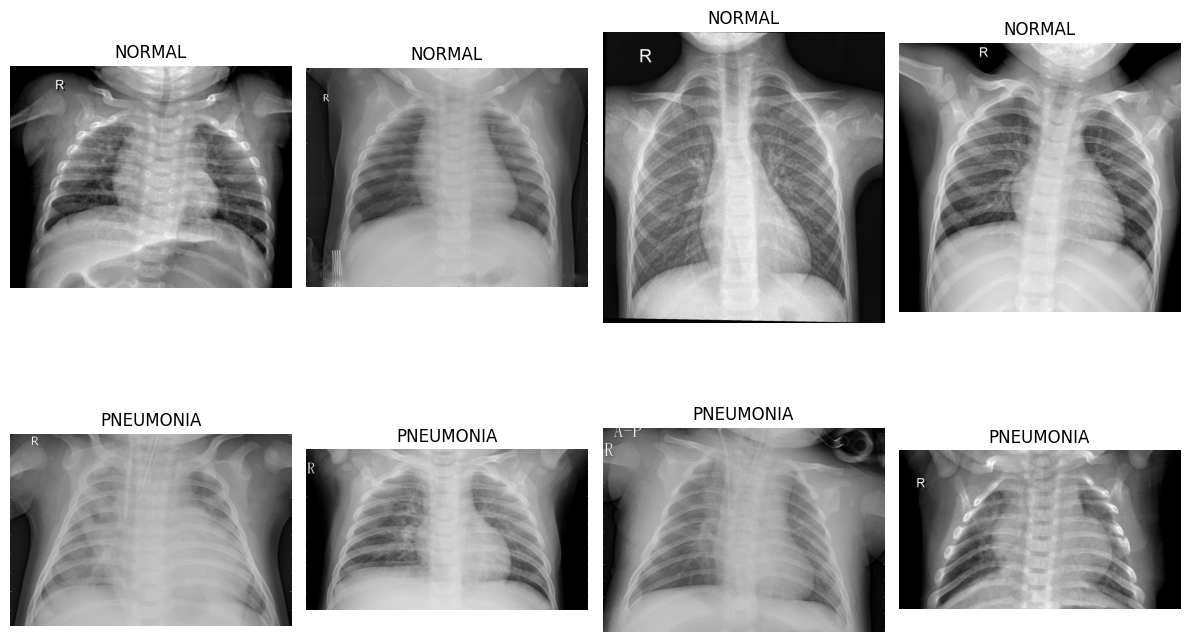

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

# Get sample image paths
normal_files = [
    os.path.join(train_path, "NORMAL", f)
    for f in os.listdir(os.path.join(train_path, "NORMAL"))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

pneumonia_files = [
    os.path.join(train_path, "PNEUMONIA", f)
    for f in os.listdir(os.path.join(train_path, "PNEUMONIA"))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Display 4 NORMAL and 4 PNEUMONIA images
plt.figure(figsize=(12, 8))

for i in range(4):
    image = Image.open(normal_files[i])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

for i in range(4):
    image = Image.open(pneumonia_files[i])

    plt.subplot(2, 4, i + 5)
    plt.imshow(image, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Step 9 — Check Image Properties

In this step, we will examine the dimensions and color mode of sample chest X-ray images. This helps us understand the image format before applying resizing and preprocessing.

In [8]:
from PIL import Image

# Select sample images
sample_normal = normal_files[0]
sample_pneumonia = pneumonia_files[0]

# Open images
normal_image = Image.open(sample_normal)
pneumonia_image = Image.open(sample_pneumonia)

print("NORMAL image size:", normal_image.size)
print("NORMAL image mode:", normal_image.mode)

print("\nPNEUMONIA image size:", pneumonia_image.size)
print("PNEUMONIA image mode:", pneumonia_image.mode)

NORMAL image size: (1148, 908)
NORMAL image mode: L

PNEUMONIA image size: (936, 640)
PNEUMONIA image mode: L


# Step 10 — Image Preprocessing

The chest X-ray images have different dimensions and are stored in grayscale format.

To prepare the images for CNN training, we will:
- Resize all images to 150 × 150 pixels.
- Convert grayscale images into a consistent image format.
- Normalize pixel values to the range 0–1.

This ensures that all images have a consistent input shape and suitable pixel values for model training.

In [9]:
IMG_SIZE = (150, 150)

print("Target image size:", IMG_SIZE)
print("Original NORMAL image size:", normal_image.size)
print("Original PNEUMONIA image size:", pneumonia_image.size)

Target image size: (150, 150)
Original NORMAL image size: (1148, 908)
Original PNEUMONIA image size: (936, 640)


# Step 11 — Create Image Preprocessing Pipeline

In this step, we will create image data pipelines that automatically resize the chest X-ray images to 150 × 150 pixels and normalize pixel values to the range 0–1.

The images will be loaded in batches to use memory efficiently.

In [10]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

print("Image preprocessing pipelines created successfully!")
print("Class names:", train_dataset.class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Image preprocessing pipelines created successfully!
Class names: ['NORMAL', 'PNEUMONIA']


# Step 12 — Verify Preprocessed Images

In this step, we will inspect one batch of images to verify the image shape, label shape, and pixel-value range before model training.

In [11]:
# Get one batch from the training dataset
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())
print("Minimum label:", tf.reduce_min(labels).numpy())
print("Maximum label:", tf.reduce_max(labels).numpy())

Image batch shape: (32, 150, 150, 1)
Label batch shape: (32, 1)
Minimum pixel value: 0.0
Maximum pixel value: 255.0
Minimum label: 0.0
Maximum label: 1.0


# Step 13 — Image Normalization

The X-ray images currently contain pixel values ranging from 0 to 255.

To make the input values suitable for neural-network training, the pixel values will be normalized to the range 0–1 by dividing them by 255.

In [12]:
# Normalize image pixel values to the range 0–1

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_normalized = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

val_normalized = val_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_normalized = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

# Verify normalization
images_norm, labels_norm = next(iter(train_normalized))

print("Image normalization applied successfully!")
print("Image shape:", images_norm.shape)
print("Minimum pixel value:", tf.reduce_min(images_norm).numpy())
print("Maximum pixel value:", tf.reduce_max(images_norm).numpy())
print("Label shape:", labels_norm.shape)

Image normalization applied successfully!
Image shape: (32, 150, 150, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Label shape: (32, 1)


# Step 14 — Data Augmentation

Data augmentation is used to create small variations of training images, helping the CNN learn more robust visual patterns and reduce overfitting.

We will apply small random rotations and zoom variations to the training images only.

In [13]:
# Create data augmentation pipeline

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10)
])

print("Data augmentation pipeline created successfully!")

Data augmentation pipeline created successfully!


# Step 15 — Final Training and Validation Pipelines

The final training pipeline combines normalized images with data augmentation.

Data augmentation is applied only to the training dataset. The validation and test datasets remain unchanged so that model performance can be evaluated fairly on unseen images.

In [14]:
# Apply data augmentation only to the training dataset

train_final = train_normalized.map(
    lambda images, labels: (data_augmentation(images, training=True), labels)
)

val_final = val_normalized
test_final = test_normalized

# Improve pipeline performance
AUTOTUNE = tf.data.AUTOTUNE

train_final = train_final.prefetch(AUTOTUNE)
val_final = val_final.prefetch(AUTOTUNE)
test_final = test_final.prefetch(AUTOTUNE)

print("Final training, validation, and testing pipelines created successfully!")

Final training, validation, and testing pipelines created successfully!


# Step 16 — CNN Model Architecture

A Convolutional Neural Network (CNN) will be developed to classify chest X-ray images into two classes: NORMAL and PNEUMONIA.

The model will use convolutional layers to learn image features, pooling layers to reduce spatial dimensions, and fully connected layers for final binary classification.

In [15]:
# Build the CNN model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,827,905 (18.42 MB)

 Trainable params: 4,827,905 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# Step 17 — Compile the CNN Model

The CNN model will be compiled using the Adam optimizer and binary cross-entropy loss because this is a binary classification problem with two classes: NORMAL and PNEUMONIA.

Accuracy will be used as the primary performance metric.

In [16]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


# Step 18 — Train the CNN Model

The CNN will now be trained on the prepared chest X-ray training dataset.

Because the training dataset contains more PNEUMONIA images than NORMAL images, class weights will be used to reduce the effect of class imbalance.

Training performance will be monitored using validation loss and validation accuracy.

In [17]:
# Calculate class weights to handle class imbalance

normal_count = 1341
pneumonia_count = 3875
total_count = normal_count + pneumonia_count

class_weight = {
    0: total_count / (2 * normal_count),
    1: total_count / (2 * pneumonia_count)
}

print("Class weights:", class_weight)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


# Step 18.1 — CNN Model Training

The CNN will be trained using the prepared training pipeline and class weights.

Early stopping will monitor validation loss and stop training when the model stops improving. The best model weights will be restored after training.

In [18]:
# Train the CNN model

EPOCHS = 20

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_final,
    validation_data=val_final,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)

print("CNN model training completed successfully!")

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 181ms/step - accuracy: 0.7122 - loss: 0.5022 - val_accuracy: 0.8750 - val_loss: 0.4188
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.9032 - loss: 0.2445 - val_accuracy: 0.8750 - val_loss: 0.4412
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 187ms/step - accuracy: 0.9155 - loss: 0.2099 - val_accuracy: 0.8750 - val_loss: 0.3214
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.9314 - loss: 0.1766 - val_accuracy: 0.9375 - val_loss: 0.2418
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.9404 - loss: 0.1566 - val_accuracy: 0.9375 - val_loss: 0.2887
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.9436 - loss: 0.1552 - val_accuracy: 1.0000 - val_loss: 0.1829
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 189ms/step - accuracy: 0.9448 - loss: 0.1344 - val_accuracy: 0.8750 - val_loss: 0.2661
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - accuracy: 0.9519 - loss: 0

# Step 19 — Training Performance Visualization

The training history will be visualized using accuracy and loss curves.

These plots help us understand the model's learning behavior and identify potential signs of overfitting or underfitting.

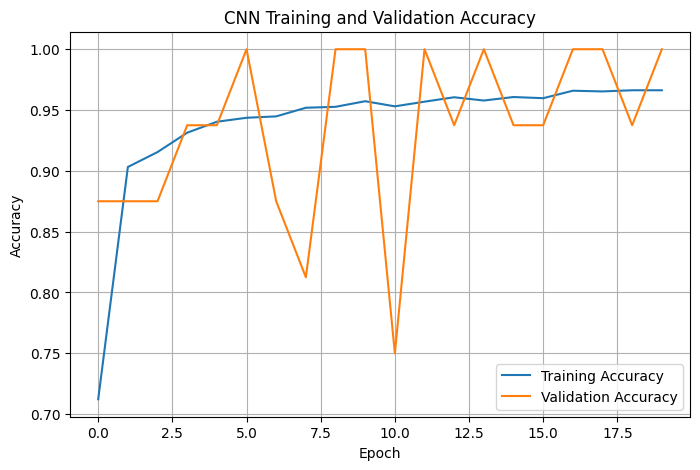

In [19]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

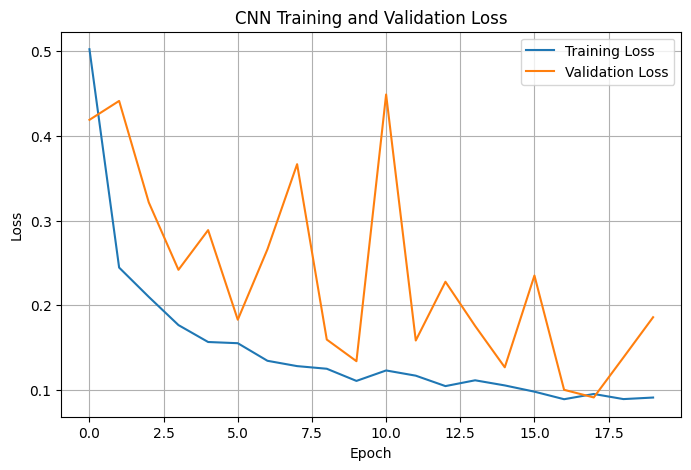

In [20]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

# Step 20 — Final Model Evaluation on Test Dataset

The trained CNN model will now be evaluated on the independent test dataset.

The test dataset contains 624 chest X-ray images that were not used during model training. Test accuracy and test loss will be used as the primary final performance measures of the model.

In [21]:
# Evaluate the CNN model on the test dataset

test_loss, test_accuracy = model.evaluate(test_final, verbose=1)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8478 - loss: 0.5239
Final Test Loss: 0.5238996148109436
Final Test Accuracy: 0.8477563858032227


# Step 21 — Generate Test Predictions

In this step, predictions will be generated for all images in the independent test dataset.

These predictions will be used to calculate the classification report and confusion matrix for a detailed evaluation of the CNN model.

In [22]:
# Generate predictions for the test dataset

y_true = []
y_pred = []

for images, labels in test_final:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten().astype(int))
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

print("Predictions generated successfully!")
print("Number of test samples:", len(y_true))

Predictions generated successfully!
Number of test samples: 624


# Step 22 — Classification Report

The classification report provides a detailed evaluation of the CNN model for the NORMAL and PNEUMONIA classes.

It includes precision, recall, F1-score, and support for each class.

In [23]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.95      0.63      0.76       234
   PNEUMONIA       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.80      0.82       624
weighted avg       0.86      0.85      0.84       624



# Step 23 — Confusion Matrix

The confusion matrix will be used to visualize the correct and incorrect predictions made by the CNN model for the NORMAL and PNEUMONIA classes.

It will help identify which type of classification error occurs most frequently.

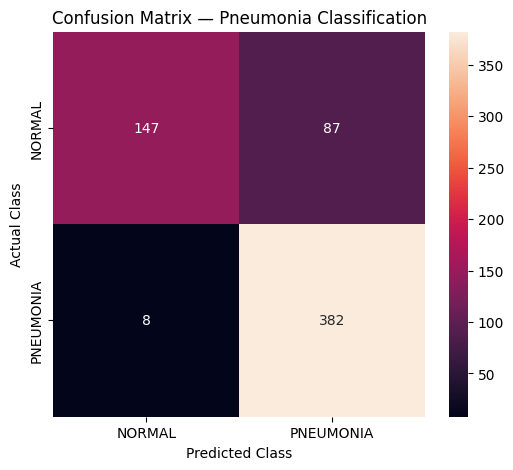

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix — Pneumonia Classification")

plt.show()

# Step 24 — Sample Image Prediction

In this step, the trained CNN model will be used to predict the class of an individual chest X-ray image.

The model will return the predicted class and prediction confidence.

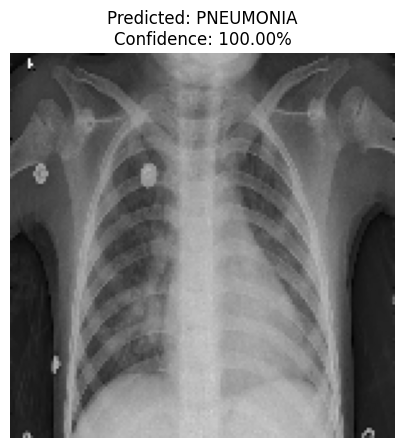

Predicted Class: PNEUMONIA
Prediction Confidence: 100.00%


In [27]:
import numpy as np

# Select one test image for prediction

sample_image_path = os.path.join(
    test_path,
    "PNEUMONIA",
    os.listdir(os.path.join(test_path, "PNEUMONIA"))[0]
)

# Load and preprocess the image
sample_image = tf.keras.utils.load_img(
    sample_image_path,
    target_size=IMG_SIZE,
    color_mode="grayscale"
)

sample_array = tf.keras.utils.img_to_array(sample_image)
sample_array = sample_array / 255.0
sample_array = np.expand_dims(sample_array, axis=0)

# Make prediction
prediction = model.predict(sample_array, verbose=0)[0][0]

if prediction >= 0.5:
    predicted_class = "PNEUMONIA"
    confidence = prediction
else:
    predicted_class = "NORMAL"
    confidence = 1 - prediction

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Prediction Confidence:", f"{confidence:.2%}")

# Step 25 — Save the Trained CNN Model

The trained CNN model will be saved in Keras format so that it can be reused for future predictions and deployment without retraining the model.

In [28]:
# Save the trained CNN model

model_path = "/content/Pneumonia_CNN_Final.keras"

model.save(model_path)

print("CNN model saved successfully!")
print("Model path:", model_path)

CNN model saved successfully!
Model path: /content/Pneumonia_CNN_Final.keras


# Step 26 — Create Class Mapping

A class mapping will be created to document the relationship between the numerical labels used by the CNN model and their corresponding class names.

This mapping will be saved as a JSON file for future prediction and deployment.

In [29]:
import json

class_mapping = {
    "0": "NORMAL",
    "1": "PNEUMONIA"
}

mapping_path = "/content/Pneumonia_CNN_Class_Mapping.json"

with open(mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Class mapping saved successfully!")
print("Mapping path:", mapping_path)
print("Class mapping:", class_mapping)

Class mapping saved successfully!
Mapping path: /content/Pneumonia_CNN_Class_Mapping.json
Class mapping: {'0': 'NORMAL', '1': 'PNEUMONIA'}


# Step 27 — Backup Final Project Files to Google Drive

The trained CNN model and class mapping file will be copied to Google Drive for permanent storage and future use.

In [30]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount("/content/drive")

# Create project folder
drive_folder = "/content/drive/MyDrive/Pneumonia_CNN_Project"
os.makedirs(drive_folder, exist_ok=True)

# Copy model and class mapping
shutil.copy(
    "/content/Pneumonia_CNN_Final.keras",
    drive_folder
)

shutil.copy(
    "/content/Pneumonia_CNN_Class_Mapping.json",
    drive_folder
)

print("Final project files saved to Google Drive successfully!")
print("\nFiles in project folder:")

for file in os.listdir(drive_folder):
    print("-", file)

Mounted at /content/drive
Final project files saved to Google Drive successfully!

Files in project folder:
- Pneumonia_CNN_Final.keras
- Pneumonia_CNN_Class_Mapping.json


# Step 28 — Project Summary

## Dataset

The project uses chest X-ray images from two classes: NORMAL and PNEUMONIA.

The dataset contains:
- Training images: 5,216
- Validation images: 16
- Test images: 624
- Total images: 5,856

The training dataset contains 1,341 NORMAL images and 3,875 PNEUMONIA images, showing a class imbalance.

## Data Preprocessing

The X-ray images were:
- Resized to 150 × 150 pixels
- Converted to grayscale format
- Normalized to pixel values between 0 and 1
- Augmented using random rotation and zoom for training

## Model

A Convolutional Neural Network (CNN) was developed using:
- Three convolutional layers
- Max-pooling layers
- A fully connected Dense layer
- Dropout regularization
- A sigmoid output layer for binary classification

The model contains 4,827,905 trainable parameters.

## Training

The CNN was trained for 20 epochs using:
- Adam optimizer
- Binary cross-entropy loss
- Class weights to address class imbalance
- Early stopping with best weights restoration

The final training accuracy was 96.63%.

## Final Test Performance

The model achieved:
- Test Accuracy: 84.78%
- Test Loss: 0.5239
- NORMAL F1-score: 0.76
- PNEUMONIA F1-score: 0.89
- Macro F1-score: 0.82
- Weighted F1-score: 0.84

The model achieved a high recall of 0.98 for the PNEUMONIA class, while NORMAL recall was 0.63.

## Key Finding

The confusion matrix showed that the model correctly classified 147 NORMAL images and 382 PNEUMONIA images. However, 87 NORMAL images were classified as PNEUMONIA and 8 PNEUMONIA images were classified as NORMAL.

## Model Storage

The trained CNN model and class mapping were saved for future use:

- Pneumonia_CNN_Final.keras
- Pneumonia_CNN_Class_Mapping.json

Both files were backed up to Google Drive.

# Step 29 — Project Conclusion

This project successfully developed a Convolutional Neural Network (CNN) to classify chest X-ray images into two categories: NORMAL and PNEUMONIA.

The images were resized to 150 × 150 pixels, converted to grayscale, normalized to the 0–1 range, and augmented using random rotation and zoom during training. Class weights were also used to address the imbalance between NORMAL and PNEUMONIA images.

The CNN achieved a training accuracy of 96.63% and a final test accuracy of 84.78%. The classification report produced a macro F1-score of 0.82 and a weighted F1-score of 0.84.

The model performed particularly well in identifying PNEUMONIA cases, achieving a recall of 0.98. However, the recall for NORMAL cases was 0.63, indicating that some NORMAL images were incorrectly classified as PNEUMONIA.

The confusion matrix showed 147 correctly classified NORMAL images and 382 correctly classified PNEUMONIA images. There were 87 NORMAL images incorrectly classified as PNEUMONIA and 8 PNEUMONIA images incorrectly classified as NORMAL.

Overall, the project demonstrates that CNN-based image classification can learn useful visual patterns from chest X-ray images and achieve strong classification performance. However, the model should be considered a machine-learning demonstration and not a medical diagnostic system.

The trained CNN model and class mapping were saved to Google Drive for future use and potential deployment.